In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../datasets/Cancer.csv')
df.drop(['Patient Id'],axis=1,inplace=True)

In [3]:
df['Level'].replace('Medium','High',inplace=True)
df['Level'].replace('High','1',inplace=True)
df['Level'].replace('Low','0',inplace=True)


/tmp/ipykernel_115129/3906274784.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Level'].replace('Medium','High',inplace=True)
/tmp/ipykernel_115129/3906274784.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [4]:
df['Level'] = pd.to_numeric(df['Level'])

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import log_loss, f1_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt 
import numpy as np 
acc_dict = {}

In [6]:
# create the data
X = df.drop('Level',axis = 1)
y = df['Level']
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [7]:
from sklearn.ensemble import  RandomForestClassifier
# create model
model = RandomForestClassifier()

In [8]:
# fit the data in the model
model.fit(X_train,y_train)

RandomForestClassifier()

Accuracy score :  99.2


/tmp/ipykernel_115129/1943955584.py:7: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(y_test,y_pred_randomF)),cmap = 'Blues',interpolation = 'nearest')


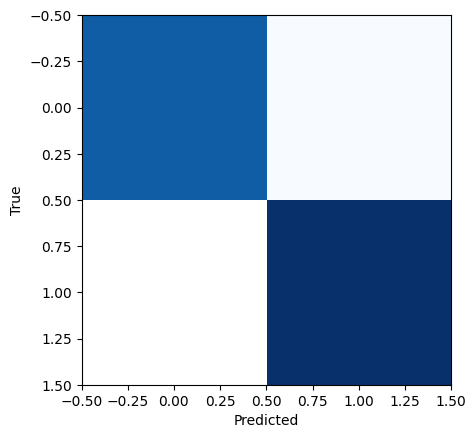

In [9]:
y_pred_randomF = model.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test, y_pred_randomF)*100)

acc_dict['RFC_log_loss'] = log_loss(y_test, y_pred_randomF)
acc_dict['RFC_F!1_Score'] = f1_score(y_test, y_pred_randomF,average='weighted')
# prediction visualization
plt.imshow(np.log(confusion_matrix(y_test,y_pred_randomF)),cmap = 'Blues',interpolation = 'nearest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [10]:
import joblib

# Save the model
joblib.dump(model, 'random.pkl')

['random.pkl']

Best k is 3 with score 0.984
Accuracy score :  99.2


/tmp/ipykernel_115129/144121188.py:24: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(y_test,y_predict)),cmap = 'Blues',interpolation = 'nearest')


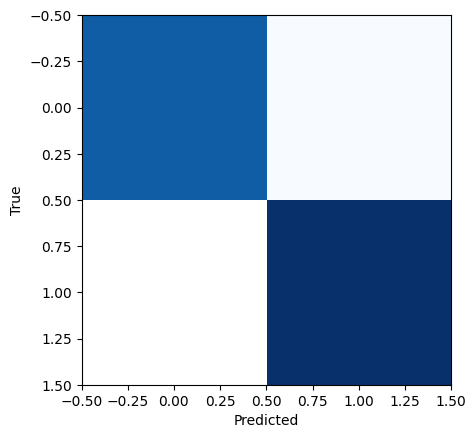

['KNN.pkl']

In [11]:
from sklearn.neighbors import KNeighborsClassifier
# to find the best k 
score = 0
scores, highscore, bestk = 0, 0, 0

for k in range(3,12):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train)
    score = scores.mean()
    if score>highscore:
        highscore = score
        bestk = k
print('Best k is {} with score {}'.format(bestk, highscore))

knn = KNeighborsClassifier(n_neighbors=bestk)
knn.fit(X_train,y_train)
# prediction 
y_predict = knn.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test,y_predict)*100)
acc_dict['KNN_log_loss'] = log_loss(y_test, y_predict)
acc_dict['KNN_F!1_Score'] = f1_score(y_test, y_predict,average='weighted')

# prediction visualization
plt.imshow(np.log(confusion_matrix(y_test,y_predict)),cmap = 'Blues',interpolation = 'nearest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

joblib.dump(model, 'KNN.pkl')

Accuracy score :  14.799999999999999


/tmp/ipykernel_115129/1972359705.py:9: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(y_test,maxx)),cmap='Reds', interpolation = 'nearest')


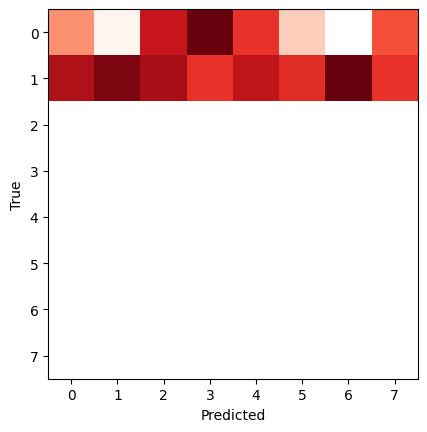

['KM.pkl']

In [12]:
from sklearn.cluster import KMeans
clf = KMeans()
clf.fit(X_train)
maxx = clf.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test,maxx)*100)
acc_dict['kMeans_log_loss'] = log_loss(y_test, maxx)
acc_dict['kMeans_F1_Score'] = f1_score(y_test, maxx,average='weighted')

plt.imshow(np.log(confusion_matrix(y_test,maxx)),cmap='Reds', interpolation = 'nearest')
plt.ylabel('True')
plt.xlabel('Predicted')

plt.show()
joblib.dump(model, 'KM.pkl')

Accuracy score :  99.2


/tmp/ipykernel_115129/2250621975.py:10: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(y_test,y_pred)),cmap = 'Blues',interpolation = 'nearest')


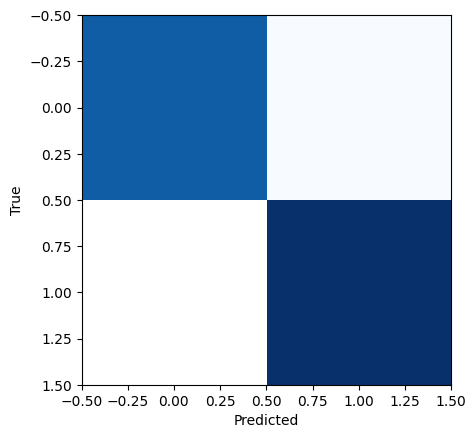

['tree.pkl']

In [13]:
from sklearn.tree import DecisionTreeClassifier
tree_ = DecisionTreeClassifier()
tree_.fit(X_train,y_train)
y_pred = tree_.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test, y_pred)*100)
acc_dict['Tree_log_loss'] = log_loss(y_test,y_pred)
acc_dict['Tree_f!1_score'] = f1_score(y_test,y_pred)

# prediction visualization
plt.imshow(np.log(confusion_matrix(y_test,y_pred)),cmap = 'Blues',interpolation = 'nearest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()
joblib.dump(model, 'tree.pkl')

Accuracy score :  97.6


/tmp/ipykernel_115129/1759217618.py:9: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(y_test,y_pred)),cmap = 'Blues',interpolation = 'nearest')


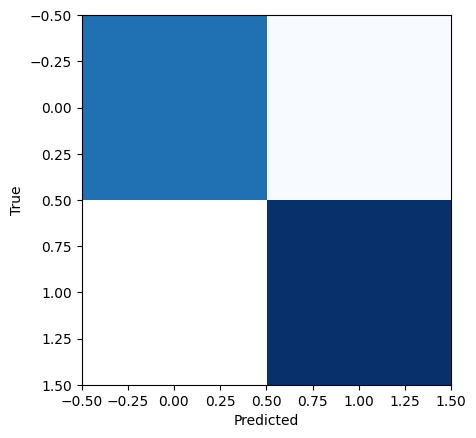

['svm.pkl']

In [14]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test, y_pred)*100)
acc_dict['svc_log_loss'] = log_loss(y_test,y_pred)
acc_dict['svc_f!1_score'] = f1_score(y_test,y_pred)
# prediction visualization
plt.imshow(np.log(confusion_matrix(y_test,y_pred)),cmap = 'Blues',interpolation = 'nearest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()
joblib.dump(model, 'svm.pkl')